# Dual Model Yield Predictor
### Desktop Version — Adapted from Google Colab

## Loading Data

In [2]:
import pandas as pd
import numpy as np
import os

# ─────────────────────────────────────────────────
# CONFIG: Path to your Data folder
# ─────────────────────────────────────────────────
DATA_FOLDER = r"C:\Users\KIIT\OneDrive\Desktop\AGRICULTURE"

# ─────────────────────────────────────────────────
# STEP 1: Build AVERAGE MEAN temperature per year
# Extracted from TEMP, HUMIDITY YEARWISE PDF reports
# ─────────────────────────────────────────────────
avg_mean_temp = {
    2005: 26.65,
    2006: 26.64,
    2007: 26.71,
    2008: 26.55,
    2009: 27.37
}

# ─────────────────────────────────────────────────
# STEP 2: Load crop_yield.csv and filter Odisha rows
#         for years 2005-2009 (temperature data years)
# ─────────────────────────────────────────────────
file_path = os.path.join(DATA_FOLDER, "crop_yield.csv")
df_raw = pd.read_csv(file_path)

# Filter: Odisha only, years with temperature data
df = df_raw[
    (df_raw['State'].str.strip().str.lower() == 'odisha') &
    (df_raw['Crop_Year'].isin(avg_mean_temp.keys()))
].copy()

# STEP 3: Add AVERAGE MEAN column
df['AVERAGE MEAN'] = df['Crop_Year'].map(avg_mean_temp)

df_processed = df.copy()

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Years: {sorted(df['Crop_Year'].unique())}")
print(f"Crops: {sorted(df['Crop'].unique())}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 140 rows x 11 columns
Years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009)]
Crops: ['Groundnut', 'Horse-gram', 'Jute', 'Maize', 'Moong(Green Gram)', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Sesamum', 'Sugarcane', 'Urad', 'Wheat']
Columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'AVERAGE MEAN']

First 5 rows:


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,AVERAGE MEAN
19245,Groundnut,2005,Autumn,Odisha,34909.0,28983,1503.4,4186287.28,7330.89,0.706000,26.65
19246,Groundnut,2005,Summer,Odisha,52720.0,74525,1503.4,6322182.40,11071.20,1.252759,26.65
19247,Groundnut,2005,Winter,Odisha,3171.0,2831,1503.4,380266.32,665.91,0.913158,26.65
19248,Horse-gram,2005,Summer,Odisha,439.0,83,1503.4,52644.88,92.19,0.217778,26.65
19249,Horse-gram,2005,Winter,Odisha,75000.0,20905,1503.4,8994000.00,15750.00,0.287667,26.65


## Pre-Processing

In [3]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode Crop and Season
encoder = OneHotEncoder(sparse_output=False, drop="first")
encoded_categorical = encoder.fit_transform(df_processed[["Crop", "Season"]])

# Convert encoded data to a DataFrame
encoded_columns = encoder.get_feature_names_out(["Crop", "Season"])
df_encoded = pd.DataFrame(encoded_categorical, columns=encoded_columns)

# Show encoded values for a few rows
print("\nOne-Hot Encoded Sample:\n", df_encoded.head())


One-Hot Encoded Sample:
    Crop_Horse-gram  Crop_Jute  Crop_Maize  Crop_Moong(Green Gram)  \
0              0.0        0.0         0.0                     0.0   
1              0.0        0.0         0.0                     0.0   
2              0.0        0.0         0.0                     0.0   
3              1.0        0.0         0.0                     0.0   
4              1.0        0.0         0.0                     0.0   

   Crop_Potato  Crop_Ragi  Crop_Rapeseed &Mustard  Crop_Rice  Crop_Sesamum  \
0          0.0        0.0                     0.0        0.0           0.0   
1          0.0        0.0                     0.0        0.0           0.0   
2          0.0        0.0                     0.0        0.0           0.0   
3          0.0        0.0                     0.0        0.0           0.0   
4          0.0        0.0                     0.0        0.0           0.0   

   Crop_Sugarcane  Crop_Urad  Crop_Wheat  Season_Summer       \
0             0.0        0

In [4]:
# Drop original categorical columns and State (only Odisha)
df_numerical = df_processed.drop(columns=["Crop", "Season", "State"])
df_numerical = df_numerical.reset_index(drop=True)
df_encoded = df_encoded.reset_index(drop=True)

# Merge encoded categorical data
df_final = pd.concat([df_numerical, df_encoded], axis=1)

# Define Features (X) and Target (Y)
X = df_final.drop(columns=["Yield"])
Y = df_final["Yield"]

print("\nFinal Processed Data (First 5 Rows):\n", df_final.head())
print("\nFeature columns:", list(X.columns))
print("\nTarget: Yield")
print(f"\nX shape: {X.shape}, Y shape: {Y.shape}")


Final Processed Data (First 5 Rows):
    Crop_Year     Area  Production  Annual_Rainfall  Fertilizer  Pesticide  \
0       2005  34909.0       28983           1503.4  4186287.28    7330.89   
1       2005  52720.0       74525           1503.4  6322182.40   11071.20   
2       2005   3171.0        2831           1503.4   380266.32     665.91   
3       2005    439.0          83           1503.4    52644.88      92.19   
4       2005  75000.0       20905           1503.4  8994000.00   15750.00   

      Yield  AVERAGE MEAN  Crop_Horse-gram  Crop_Jute  ...  Crop_Potato  \
0  0.706000         26.65              0.0        0.0  ...          0.0   
1  1.252759         26.65              0.0        0.0  ...          0.0   
2  0.913158         26.65              0.0        0.0  ...          0.0   
3  0.217778         26.65              1.0        0.0  ...          0.0   
4  0.287667         26.65              1.0        0.0  ...          0.0   

   Crop_Ragi  Crop_Rapeseed &Mustard  Crop_Rice

In [5]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Show a small sample after scaling
print("\nScaled Features Sample:\n", X_scaled_df.head())


Scaled Features Sample:
    Crop_Year      Area  Production  Annual_Rainfall  Fertilizer  Pesticide  \
0  -1.414214 -0.238563   -0.263121        -0.316051   -0.243633  -0.217668   
1  -1.414214 -0.210439   -0.219094        -0.316051   -0.218956  -0.184188   
2  -1.414214 -0.288677   -0.288403        -0.316051   -0.287607  -0.277326   
3  -1.414214 -0.292991   -0.291060        -0.316051   -0.291392  -0.282461   
4  -1.414214 -0.175259   -0.270930        -0.316051   -0.188087  -0.142308   

   AVERAGE MEAN  Crop_Horse-gram  Crop_Jute  Crop_Maize  ...  Crop_Potato  \
0     -0.450528        -0.277350   -0.19245    -0.34641  ...     -0.19245   
1     -0.450528        -0.277350   -0.19245    -0.34641  ...     -0.19245   
2     -0.450528        -0.277350   -0.19245    -0.34641  ...     -0.19245   
3     -0.450528         3.605551   -0.19245    -0.34641  ...     -0.19245   
4     -0.450528         3.605551   -0.19245    -0.34641  ...     -0.19245   

   Crop_Ragi  Crop_Rapeseed &Mustard  Crop

## Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# Show the number of samples in each set
print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# Verify the first few samples
print("\nX_train Sample:\n", X_train[:5])
print("\nY_train Sample:\n", Y_train[:5])


Training Samples: 112
Testing Samples: 28

X_train Sample:
 [[-1.41421356 -0.26620806 -0.28792078 -0.31605112 -0.26789074 -0.25057763
  -0.45052771 -0.2773501  -0.19245009 -0.34641016 -0.34641016 -0.19245009
  -0.34641016  5.19615242 -0.34641016 -0.34641016 -0.19245009 -0.34641016
  -0.19245009 -0.6882472   1.24316312]
 [-1.41421356  0.21949452  0.38751244 -0.31605112  0.15829151  0.32761875
  -0.45052771 -0.2773501  -0.19245009 -0.34641016 -0.34641016 -0.19245009
  -0.34641016 -0.19245009  2.88675135 -0.34641016 -0.19245009 -0.34641016
  -0.19245009  1.45296631 -0.80439967]
 [-1.41421356 -0.08483482 -0.25004482 -0.31605112 -0.10874385 -0.03466494
  -0.45052771 -0.2773501  -0.19245009 -0.34641016  2.88675135 -0.19245009
  -0.34641016 -0.19245009 -0.34641016 -0.34641016 -0.19245009 -0.34641016
  -0.19245009  1.45296631 -0.80439967]
 [ 0.70710678 -0.2853678  -0.28399968 -0.04348765 -0.28329563 -0.27904339
  -0.78674243 -0.2773501  -0.19245009 -0.34641016 -0.34641016 -0.19245009
  -0.346

In [7]:
import pandas as pd

# Save the training and testing sets to CSV files (local Desktop version)
output_dir = DATA_FOLDER
os.makedirs(output_dir, exist_ok=True)

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)
Y_train_df = pd.DataFrame(Y_train)
Y_test_df  = pd.DataFrame(Y_test)

X_train_df.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test_df.to_csv( os.path.join(output_dir, 'X_test.csv'),  index=False)
Y_train_df.to_csv(os.path.join(output_dir, 'Y_train.csv'), index=False)
Y_test_df.to_csv( os.path.join(output_dir, 'Y_test.csv'),  index=False)

print("\nSample of X_train:\n", X_train_df.head(5))
print("\nSample of Y_train:\n", Y_train_df.head(5))
print(f"\nTrain/test CSVs saved to: {os.path.abspath(output_dir)}")


Sample of X_train:
    Crop_Year      Area  Production  Annual_Rainfall  Fertilizer  Pesticide  \
0  -1.414214 -0.266208   -0.287921        -0.316051   -0.267891  -0.250578   
1  -1.414214  0.219495    0.387512        -0.316051    0.158292   0.327619   
2  -1.414214 -0.084835   -0.250045        -0.316051   -0.108744  -0.034665   
3   0.707107 -0.285368   -0.284000        -0.043488   -0.283296  -0.279043   
4   0.707107  0.822677    0.419415        -0.043488    0.876411   0.286265   

   AVERAGE MEAN  Crop_Horse-gram  Crop_Jute  Crop_Maize  ...  Crop_Potato  \
0     -0.450528         -0.27735   -0.19245    -0.34641  ...     -0.19245   
1     -0.450528         -0.27735   -0.19245    -0.34641  ...     -0.19245   
2     -0.450528         -0.27735   -0.19245    -0.34641  ...     -0.19245   
3     -0.786742         -0.27735   -0.19245    -0.34641  ...     -0.19245   
4     -0.786742         -0.27735   -0.19245    -0.34641  ...     -0.19245   

   Crop_Ragi  Crop_Rapeseed &Mustard  Crop_Rice

## Model — Random Forest

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Build and train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train Random Forest
rf_model.fit(X_train, Y_train)

# Make predictions using Random Forest
rf_predictions = rf_model.predict(X_test)

# Evaluate Random Forest
rf_mae  = mean_absolute_error(Y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_predictions))
print("Random Forest MAE:",  rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 0.08604708418000005
Random Forest RMSE: 0.15121181299958


In [9]:
from sklearn.metrics import r2_score

# Calculate R² for Random Forest
rf_r2 = r2_score(Y_test, rf_predictions)

# Calculate Accuracy in percentage (Relative MAE)
rf_accuracy_percent = (1 - (rf_mae / Y_test.mean())) * 100

print("Random Forest R²: ",                rf_r2)
print("Random Forest Accuracy (in %): ",   rf_accuracy_percent)

Random Forest R²:  0.9954523271845056
Random Forest Accuracy (in %):  92.97901773502448


In [10]:
# Calculate Mean Absolute Percentage Error (MAPE) for Random Forest
rf_mape = np.mean(np.abs((Y_test.values.flatten() - rf_predictions) / Y_test.values.flatten())) * 100

print("Random Forest MAPE (in %):", rf_mape)

Random Forest MAPE (in %): 15.771991177713012


Random Forest MAE: 0.08604708418000005
Random Forest RMSE: 0.15121181299958
Random Forest R²: 0.9954523271845056
Random Forest Accuracy (in %): 92.97901773502448
Random Forest MAPE (in %): 15.771991177713012


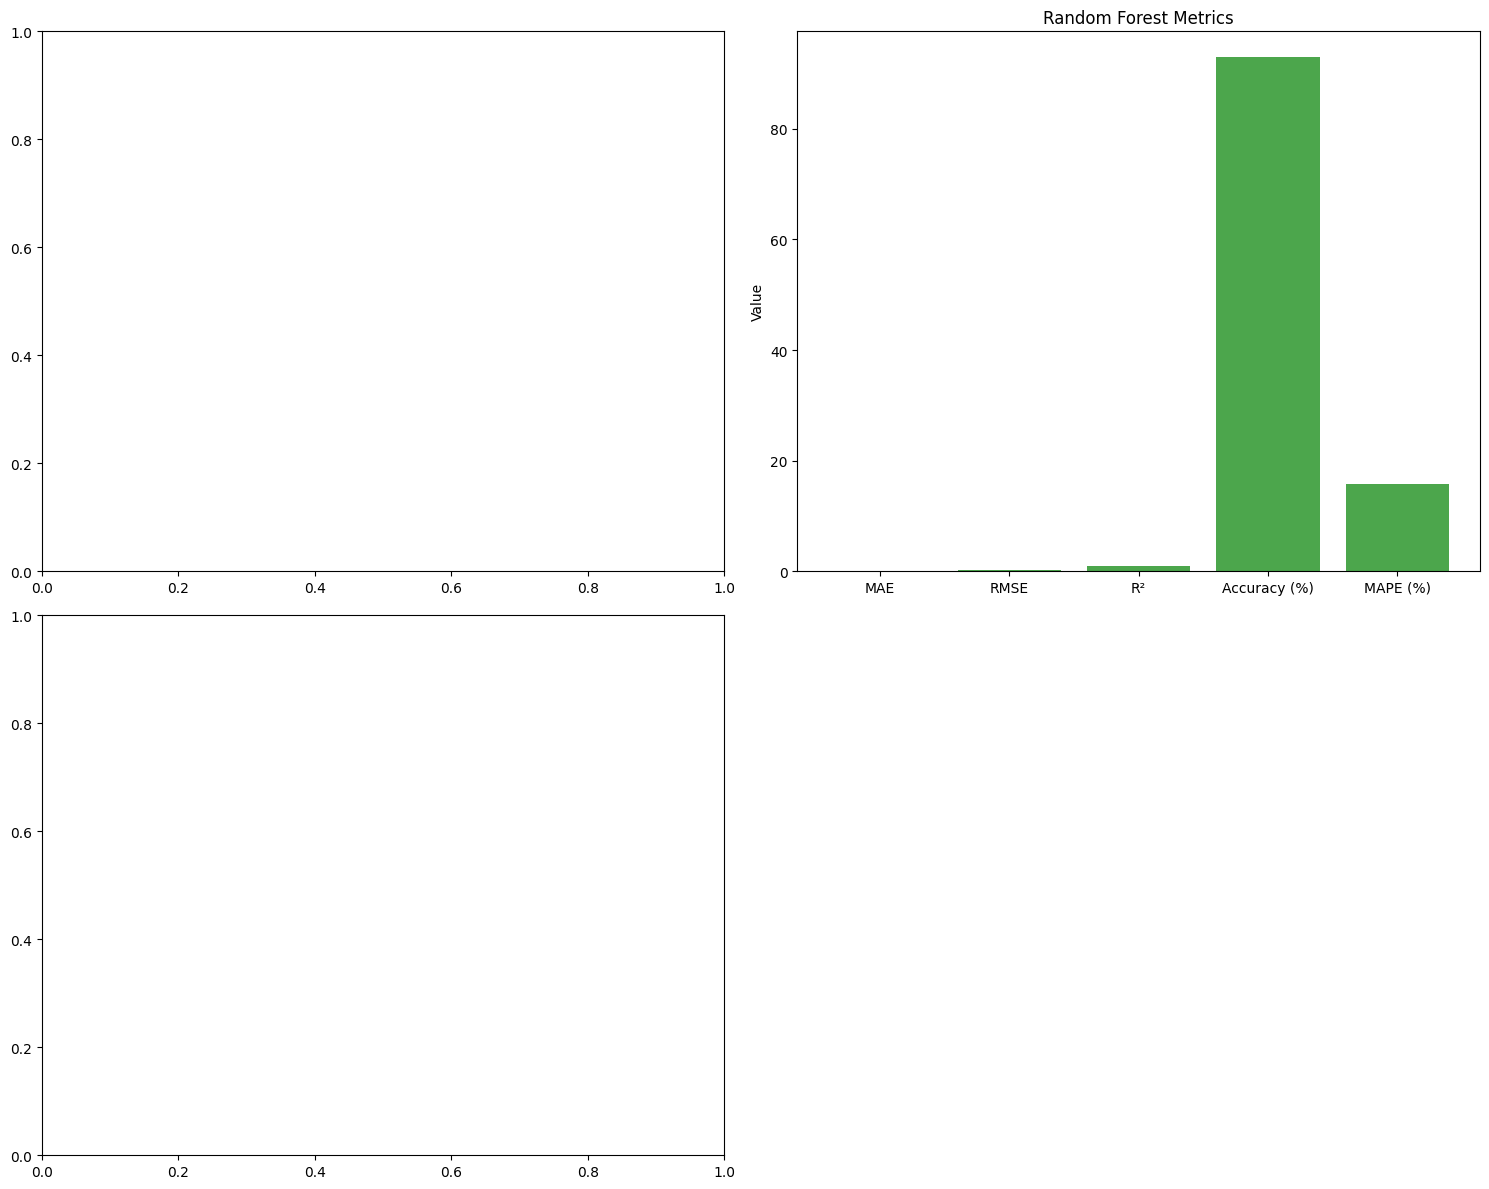

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# Evaluate Random Forest
rf_mae            = mean_absolute_error(Y_test, rf_predictions)
rf_rmse           = np.sqrt(mean_squared_error(Y_test, rf_predictions))
rf_r2             = r2_score(Y_test, rf_predictions)
rf_accuracy_percent = (1 - (rf_mae / Y_test.mean())) * 100
rf_mape           = np.mean(np.abs((Y_test.values.flatten() - rf_predictions) / Y_test.values.flatten())) * 100

print("Random Forest MAE:",             rf_mae)
print("Random Forest RMSE:",            rf_rmse)
print("Random Forest R²:",             rf_r2)
print("Random Forest Accuracy (in %):", rf_accuracy_percent)
print("Random Forest MAPE (in %):",     rf_mape)

# Visualizing Metrics
metrics   = ['MAE', 'RMSE', 'R²', 'Accuracy (%)', 'MAPE (%)']
rf_values = [rf_mae, rf_rmse, rf_r2, rf_accuracy_percent, rf_mape]

fig, ax = plt.subplots(2, 2, figsize=(15, 12))

ax[0, 1].bar(metrics, rf_values, color='green', alpha=0.7, label='Random Forest')
ax[0, 1].set_title('Random Forest Metrics')
ax[0, 1].set_ylabel('Value')

fig.delaxes(ax[1, 1])

plt.tight_layout()
plt.show()

In [12]:
# Display first 10 sample predictions for Random Forest
import pandas as pd

results_df = pd.DataFrame({
    'True Values':               Y_test.values.flatten(),
    'Random Forest Predictions': rf_predictions.flatten()
})

print("Sample Predictions:")
print(results_df.head(10))

Sample Predictions:
   True Values  Random Forest Predictions
0     0.241250                   0.237659
1     0.254074                   0.257915
2     0.242857                   0.244027
3     1.505217                   1.486980
4     0.590000                   0.669267
5     8.475517                   8.921057
6     0.276522                   0.296236
7     0.541000                   0.553542
8     0.156875                   0.417722
9     0.310000                   0.437139


## Model Architecture

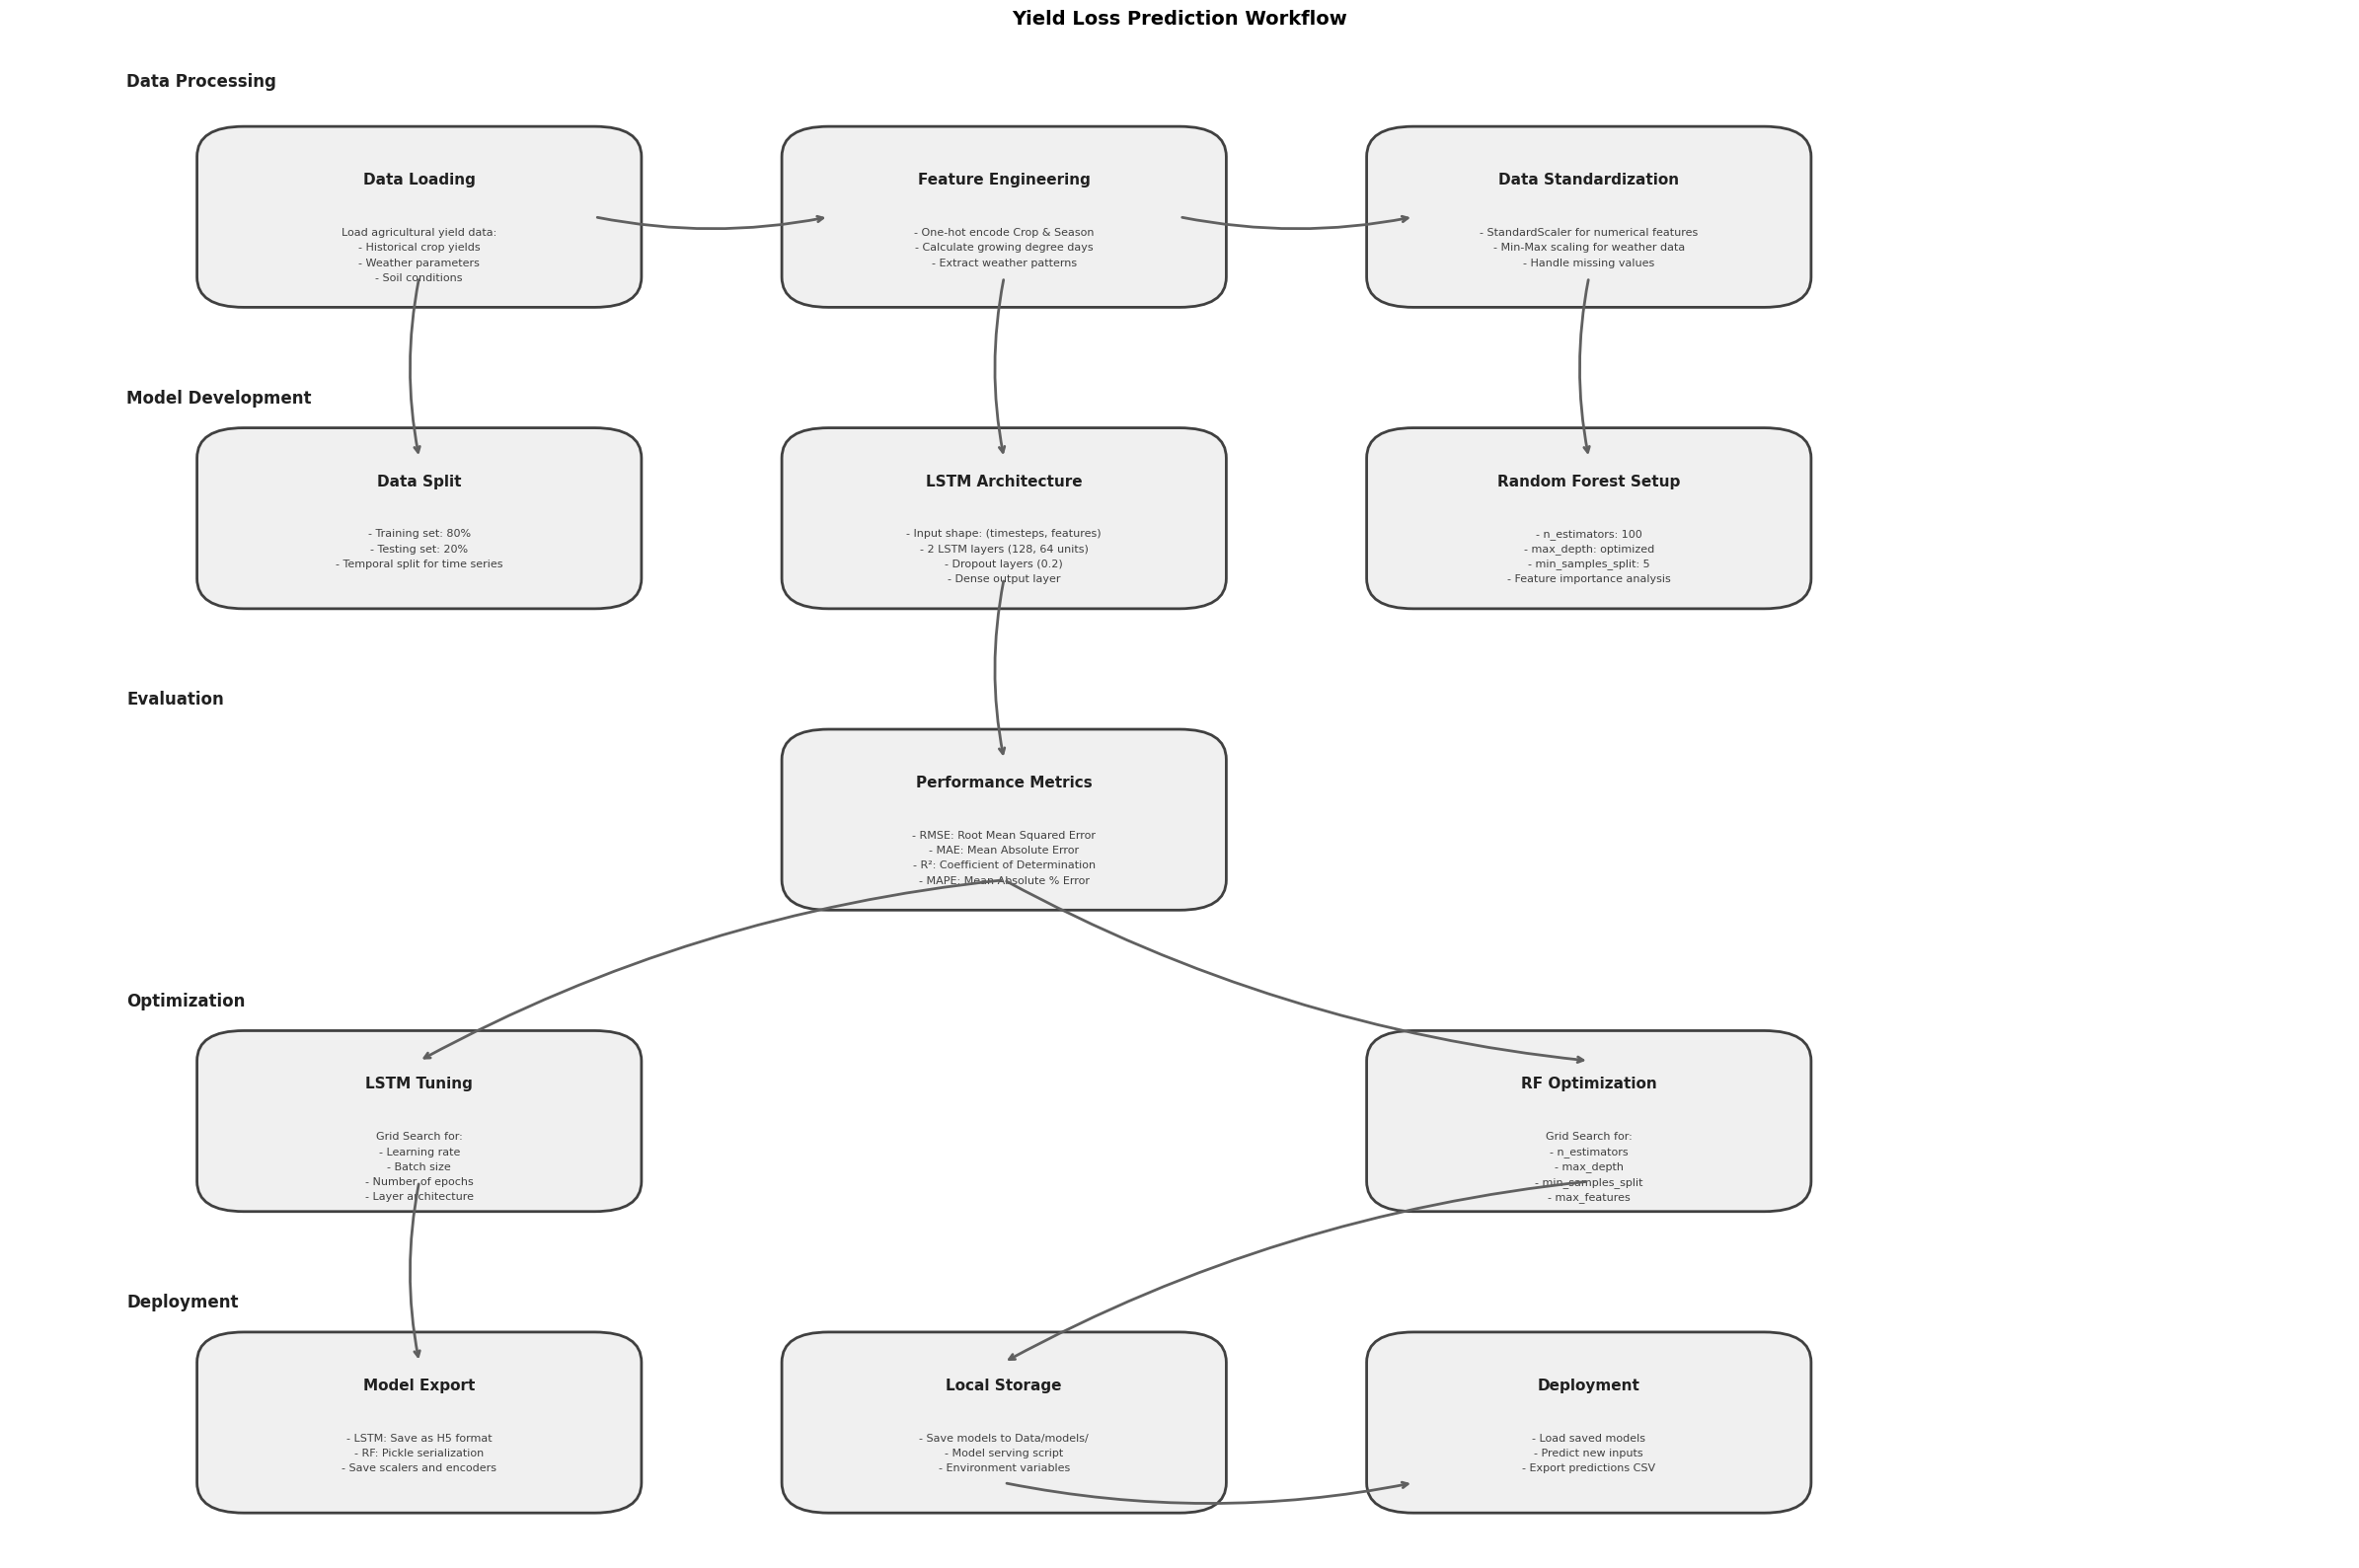

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(24, 16))

boxes = [
    {"name": "Data Loading",
     "description": "Load agricultural yield data:\n- Historical crop yields\n- Weather parameters\n- Soil conditions",
     "xy": (0.1, 0.85), "width": 0.15, "height": 0.08},
    {"name": "Feature Engineering",
     "description": "- One-hot encode Crop & Season\n- Calculate growing degree days\n- Extract weather patterns",
     "xy": (0.35, 0.85), "width": 0.15, "height": 0.08},
    {"name": "Data Standardization",
     "description": "- StandardScaler for numerical features\n- Min-Max scaling for weather data\n- Handle missing values",
     "xy": (0.6, 0.85), "width": 0.15, "height": 0.08},
    {"name": "Data Split",
     "description": "- Training set: 80%\n- Testing set: 20%\n- Temporal split for time series",
     "xy": (0.1, 0.65), "width": 0.15, "height": 0.08},
    {"name": "LSTM Architecture",
     "description": "- Input shape: (timesteps, features)\n- 2 LSTM layers (128, 64 units)\n- Dropout layers (0.2)\n- Dense output layer",
     "xy": (0.35, 0.65), "width": 0.15, "height": 0.08},
    {"name": "Random Forest Setup",
     "description": "- n_estimators: 100\n- max_depth: optimized\n- min_samples_split: 5\n- Feature importance analysis",
     "xy": (0.6, 0.65), "width": 0.15, "height": 0.08},
    {"name": "Performance Metrics",
     "description": "- RMSE: Root Mean Squared Error\n- MAE: Mean Absolute Error\n- R²: Coefficient of Determination\n- MAPE: Mean Absolute % Error",
     "xy": (0.35, 0.45), "width": 0.15, "height": 0.08},
    {"name": "LSTM Tuning",
     "description": "Grid Search for:\n- Learning rate\n- Batch size\n- Number of epochs\n- Layer architecture",
     "xy": (0.1, 0.25), "width": 0.15, "height": 0.08},
    {"name": "RF Optimization",
     "description": "Grid Search for:\n- n_estimators\n- max_depth\n- min_samples_split\n- max_features",
     "xy": (0.6, 0.25), "width": 0.15, "height": 0.08},
    {"name": "Model Export",
     "description": "- LSTM: Save as H5 format\n- RF: Pickle serialization\n- Save scalers and encoders",
     "xy": (0.1, 0.05), "width": 0.15, "height": 0.08},
    {"name": "Local Storage",
     "description": "- Save models to Data/models/\n- Model serving script\n- Environment variables",
     "xy": (0.35, 0.05), "width": 0.15, "height": 0.08},
    {"name": "Deployment",
     "description": "- Load saved models\n- Predict new inputs\n- Export predictions CSV",
     "xy": (0.6, 0.05), "width": 0.15, "height": 0.08},
]

for box in boxes:
    ax.add_patch(patches.FancyBboxPatch(
        box["xy"], box["width"], box["height"],
        boxstyle="round,pad=0.02",
        facecolor='#f0f0f0', edgecolor='#404040', linewidth=2
    ))
    ax.text(box["xy"][0] + box["width"]/2, box["xy"][1] + box["height"] - 0.015,
            box["name"], ha="center", va="center", fontsize=11, fontweight='bold', color='#202020')
    desc_lines = box["description"].split('\n')
    for i, line in enumerate(desc_lines):
        ax.text(box["xy"][0] + box["width"]/2, box["xy"][1] + box["height"]/2 - 0.01 - (i * 0.01),
                line, ha="center", va="center", fontsize=8, color='#404040')

arrows = [
    {"start": (0.25, 0.89), "end": (0.35, 0.89)},
    {"start": (0.5, 0.89),  "end": (0.6, 0.89)},
    {"start": (0.175, 0.85), "end": (0.175, 0.73)},
    {"start": (0.425, 0.85), "end": (0.425, 0.73)},
    {"start": (0.675, 0.85), "end": (0.675, 0.73)},
    {"start": (0.425, 0.65), "end": (0.425, 0.53)},
    {"start": (0.425, 0.45), "end": (0.175, 0.33)},
    {"start": (0.425, 0.45), "end": (0.675, 0.33)},
    {"start": (0.175, 0.25), "end": (0.175, 0.13)},
    {"start": (0.675, 0.25), "end": (0.425, 0.13)},
    {"start": (0.425, 0.05), "end": (0.6, 0.05)},
]
for arrow in arrows:
    ax.annotate("", xy=arrow["end"], xytext=arrow["start"],
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.1", color='#606060', lw=2))

phases = [
    {"name": "Data Processing",   "xy": (0.05, 0.98)},
    {"name": "Model Development", "xy": (0.05, 0.77)},
    {"name": "Evaluation",        "xy": (0.05, 0.57)},
    {"name": "Optimization",      "xy": (0.05, 0.37)},
    {"name": "Deployment",        "xy": (0.05, 0.17)}
]
for phase in phases:
    ax.text(phase["xy"][0], phase["xy"][1], phase["name"],
            ha="left", va="center", fontsize=12, fontweight='bold', color='#202020')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.title("Yield Loss Prediction Workflow", pad=20, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Model LSTM

c:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 397ms/step - loss: 111.5059 - val_loss: 269.4708 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 97.4012 - val_loss: 269.4036 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 91.2462 - val_loss: 269.3536 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 87.3232 - val_loss: 269.3884 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 82.3577 - val_loss: 269.4258 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 82.5180 - val_loss: 269.4830 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 86.6555 - val_loss: 269.5250 - learning_rate: 0.0010
Epoch 8/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 58.1059
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 78.0780 - val_loss: 269.5643 - l

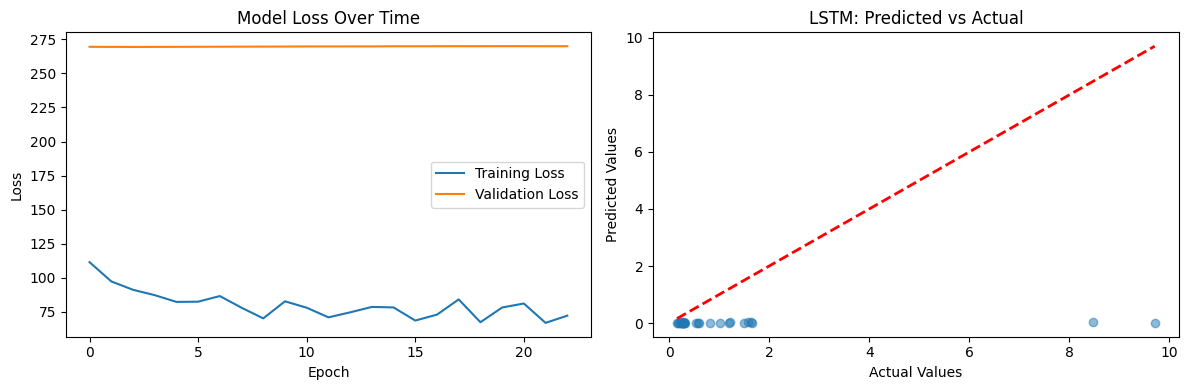

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reshape data for LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0],  1, X_test.shape[1]))

# Build improved LSTM Model
lstm_model = Sequential([
    LSTM(128, activation='relu', return_sequences=True,
         input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)
lstm_model.compile(optimizer=optimizer, loss='mse')

early_stopping = EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001, verbose=1)

history = lstm_model.fit(
    X_train_lstm, Y_train,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

lstm_predictions = lstm_model.predict(X_test_lstm)

lstm_mae            = mean_absolute_error(Y_test, lstm_predictions)
lstm_rmse           = np.sqrt(mean_squared_error(Y_test, lstm_predictions))
lstm_r2             = r2_score(Y_test, lstm_predictions)
lstm_accuracy_percent = (1 - (lstm_mae / Y_test.mean())) * 100
lstm_mape           = np.mean(np.abs((Y_test.values.flatten() - lstm_predictions.flatten()) / Y_test.values.flatten())) * 100

print("\nLSTM Model Performance:")
print(f"MAE:          {lstm_mae:.4f}")
print(f"RMSE:         {lstm_rmse:.4f}")
print(f"R²:           {lstm_r2:.4f}")
print(f"Accuracy (%): {lstm_accuracy_percent:.2f}")
print(f"MAPE (%):     {lstm_mape:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(Y_test, lstm_predictions, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('LSTM: Predicted vs Actual')

plt.tight_layout()
plt.show()

## RF Visualization

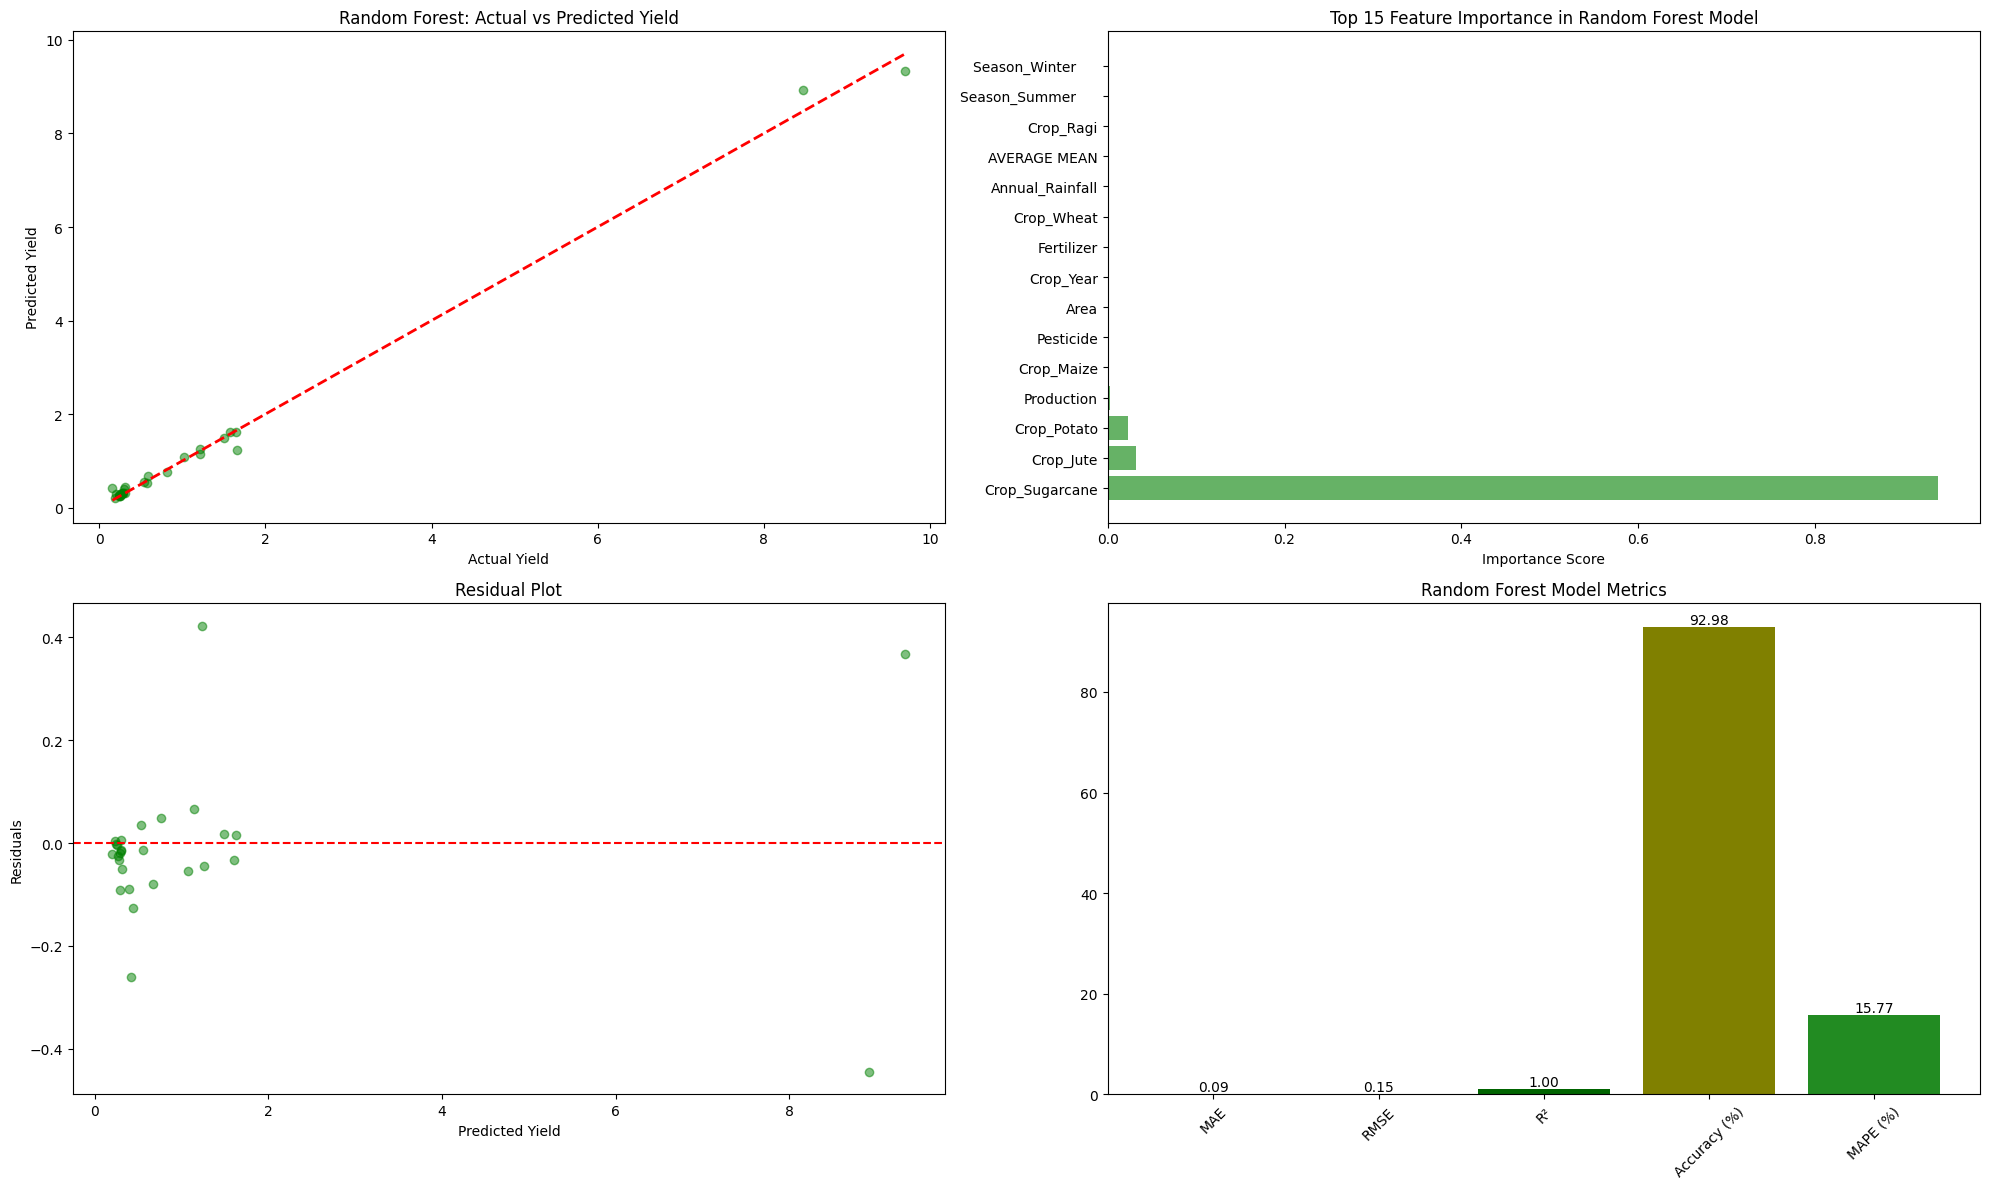

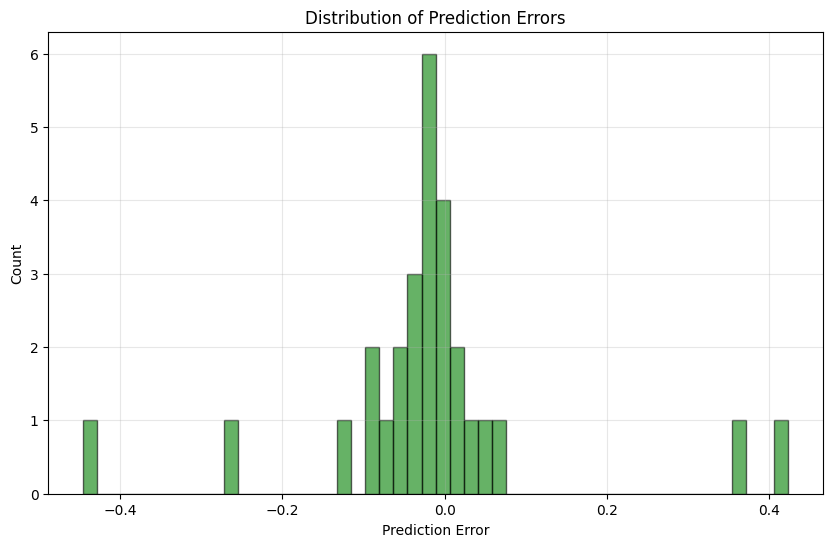

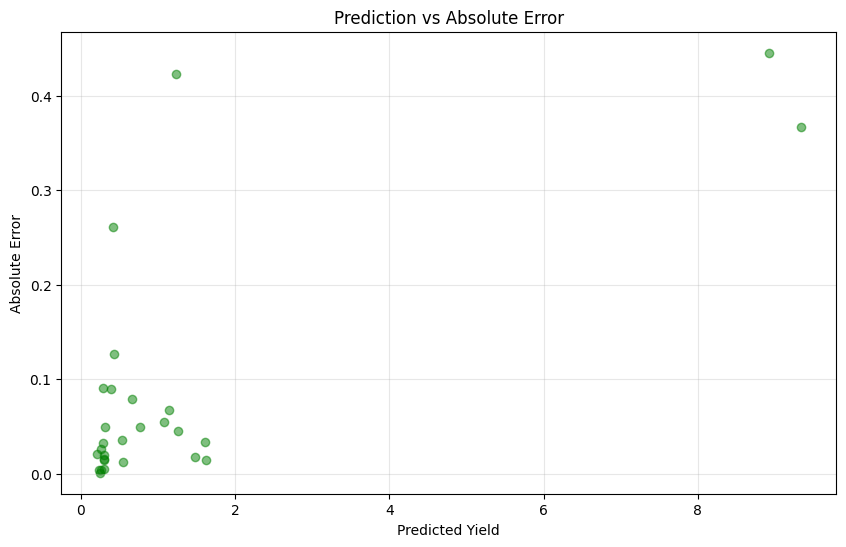

C:\Users\KIIT\AppData\Local\Temp\ipykernel_20764\1961392011.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])


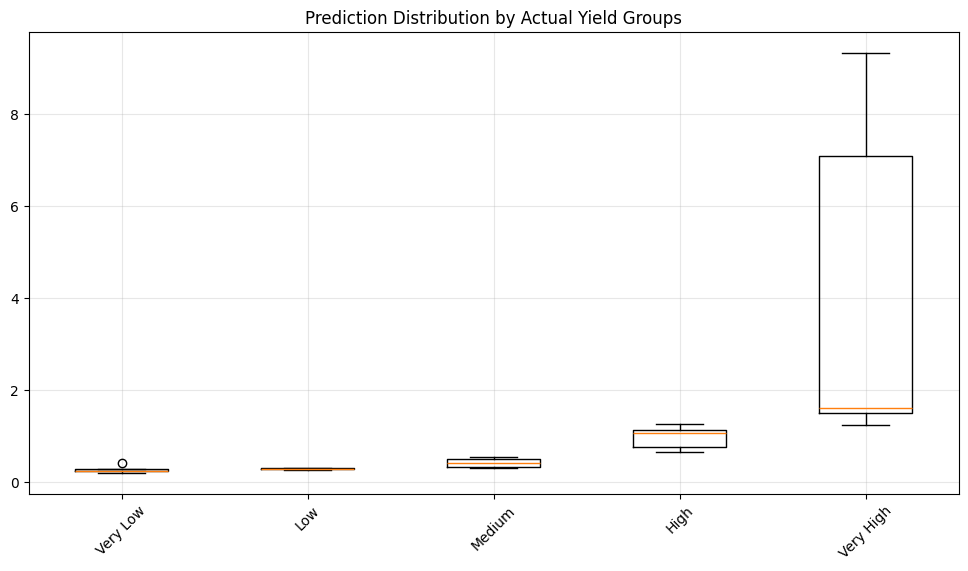

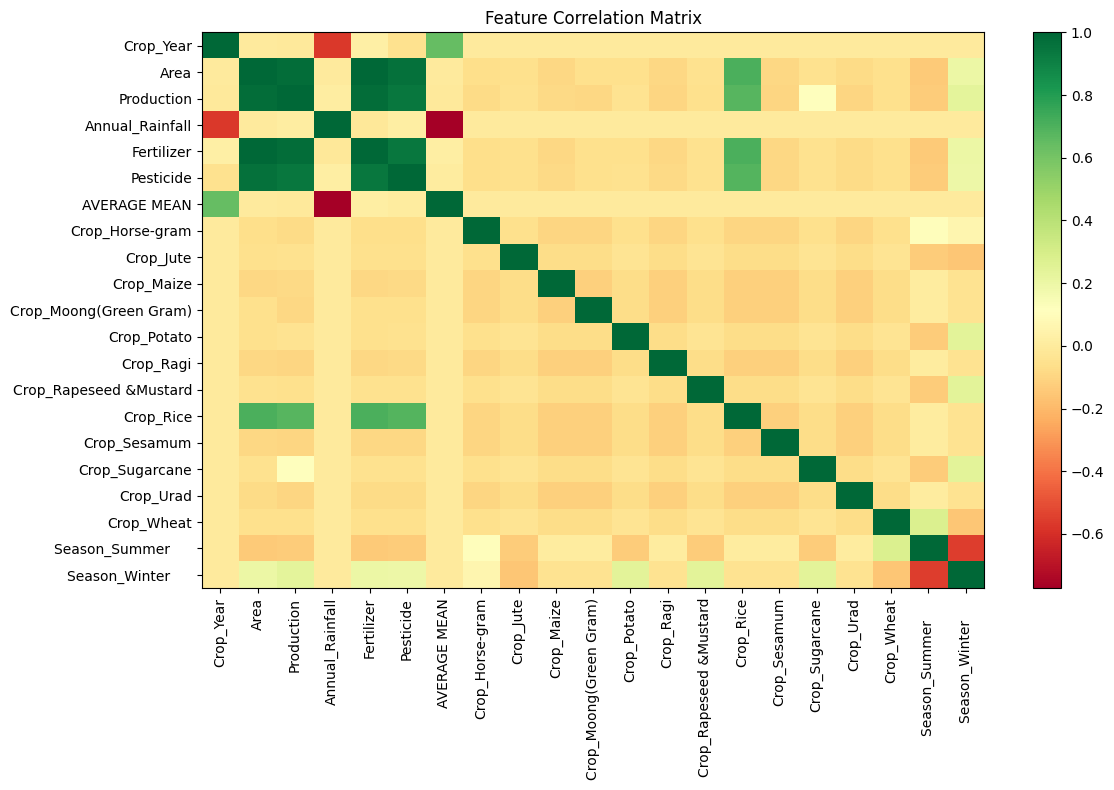


Random Forest Model Performance Metrics:
Mean Absolute Error (MAE): 0.0860
Root Mean Square Error (RMSE): 0.1512
R² Score: 0.9955
Model Accuracy: 92.98%
Mean Absolute Percentage Error (MAPE): 15.77%


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae            = mean_absolute_error(Y_test, rf_predictions)
rf_rmse           = np.sqrt(mean_squared_error(Y_test, rf_predictions))
rf_r2             = r2_score(Y_test, rf_predictions)
rf_accuracy_percent = (1 - (rf_mae / Y_test.mean())) * 100
rf_mape           = np.mean(np.abs((Y_test.values.flatten() - rf_predictions) / Y_test.values.flatten())) * 100

plt.style.use('default')
fig = plt.figure(figsize=(20, 12))

ax1 = plt.subplot(2, 2, 1)
plt.scatter(Y_test, rf_predictions, alpha=0.5, color='green')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Random Forest: Actual vs Predicted Yield')

ax2 = plt.subplot(2, 2, 2)
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(15)
plt.barh(range(len(feature_importance)), feature_importance['importance'], color='green', alpha=0.6)
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.title('Top 15 Feature Importance in Random Forest Model')
plt.xlabel('Importance Score')

ax3 = plt.subplot(2, 2, 3)
residuals = Y_test - rf_predictions
plt.scatter(rf_predictions, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Yield')
plt.ylabel('Residuals')
plt.title('Residual Plot')

ax4 = plt.subplot(2, 2, 4)
metrics = ['MAE', 'RMSE', 'R²', 'Accuracy (%)', 'MAPE (%)']
values  = [rf_mae, rf_rmse, rf_r2, rf_accuracy_percent, rf_mape]
colors  = ['lightgreen', 'green', 'darkgreen', 'olive', 'forestgreen']
bars = plt.bar(metrics, values, color=colors)
plt.xticks(rotation=45)
plt.title('Random Forest Model Metrics')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, color='green', alpha=0.6, edgecolor='black')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(rf_predictions, np.abs(residuals), alpha=0.5, color='green')
plt.title('Prediction vs Absolute Error')
plt.xlabel('Predicted Yield')
plt.ylabel('Absolute Error')
plt.grid(True, alpha=0.3)
plt.show()

def create_yield_groups(y):
    return pd.qcut(y, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

results_rf = pd.DataFrame({'Actual': Y_test, 'Predicted': rf_predictions,
                            'Yield_Group': create_yield_groups(Y_test)})
plt.figure(figsize=(12, 6))
box_data = [results_rf[results_rf['Yield_Group'] == g]['Predicted']
            for g in ['Very Low', 'Low', 'Medium', 'High', 'Very High']]
plt.boxplot(box_data, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
plt.title('Prediction Distribution by Actual Yield Groups')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

numeric_features    = X.select_dtypes(include=[np.number]).columns
correlation_matrix  = X[numeric_features].corr()
plt.figure(figsize=(12, 8))
im = plt.imshow(correlation_matrix, cmap='RdYlGn', aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nRandom Forest Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {rf_mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")
print(f"Model Accuracy: {rf_accuracy_percent:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE): {rf_mape:.2f}%")

feature_importance.to_csv(os.path.join(DATA_FOLDER, 'random_forest_feature_importance.csv'), index=False)

## LSTM Visualization

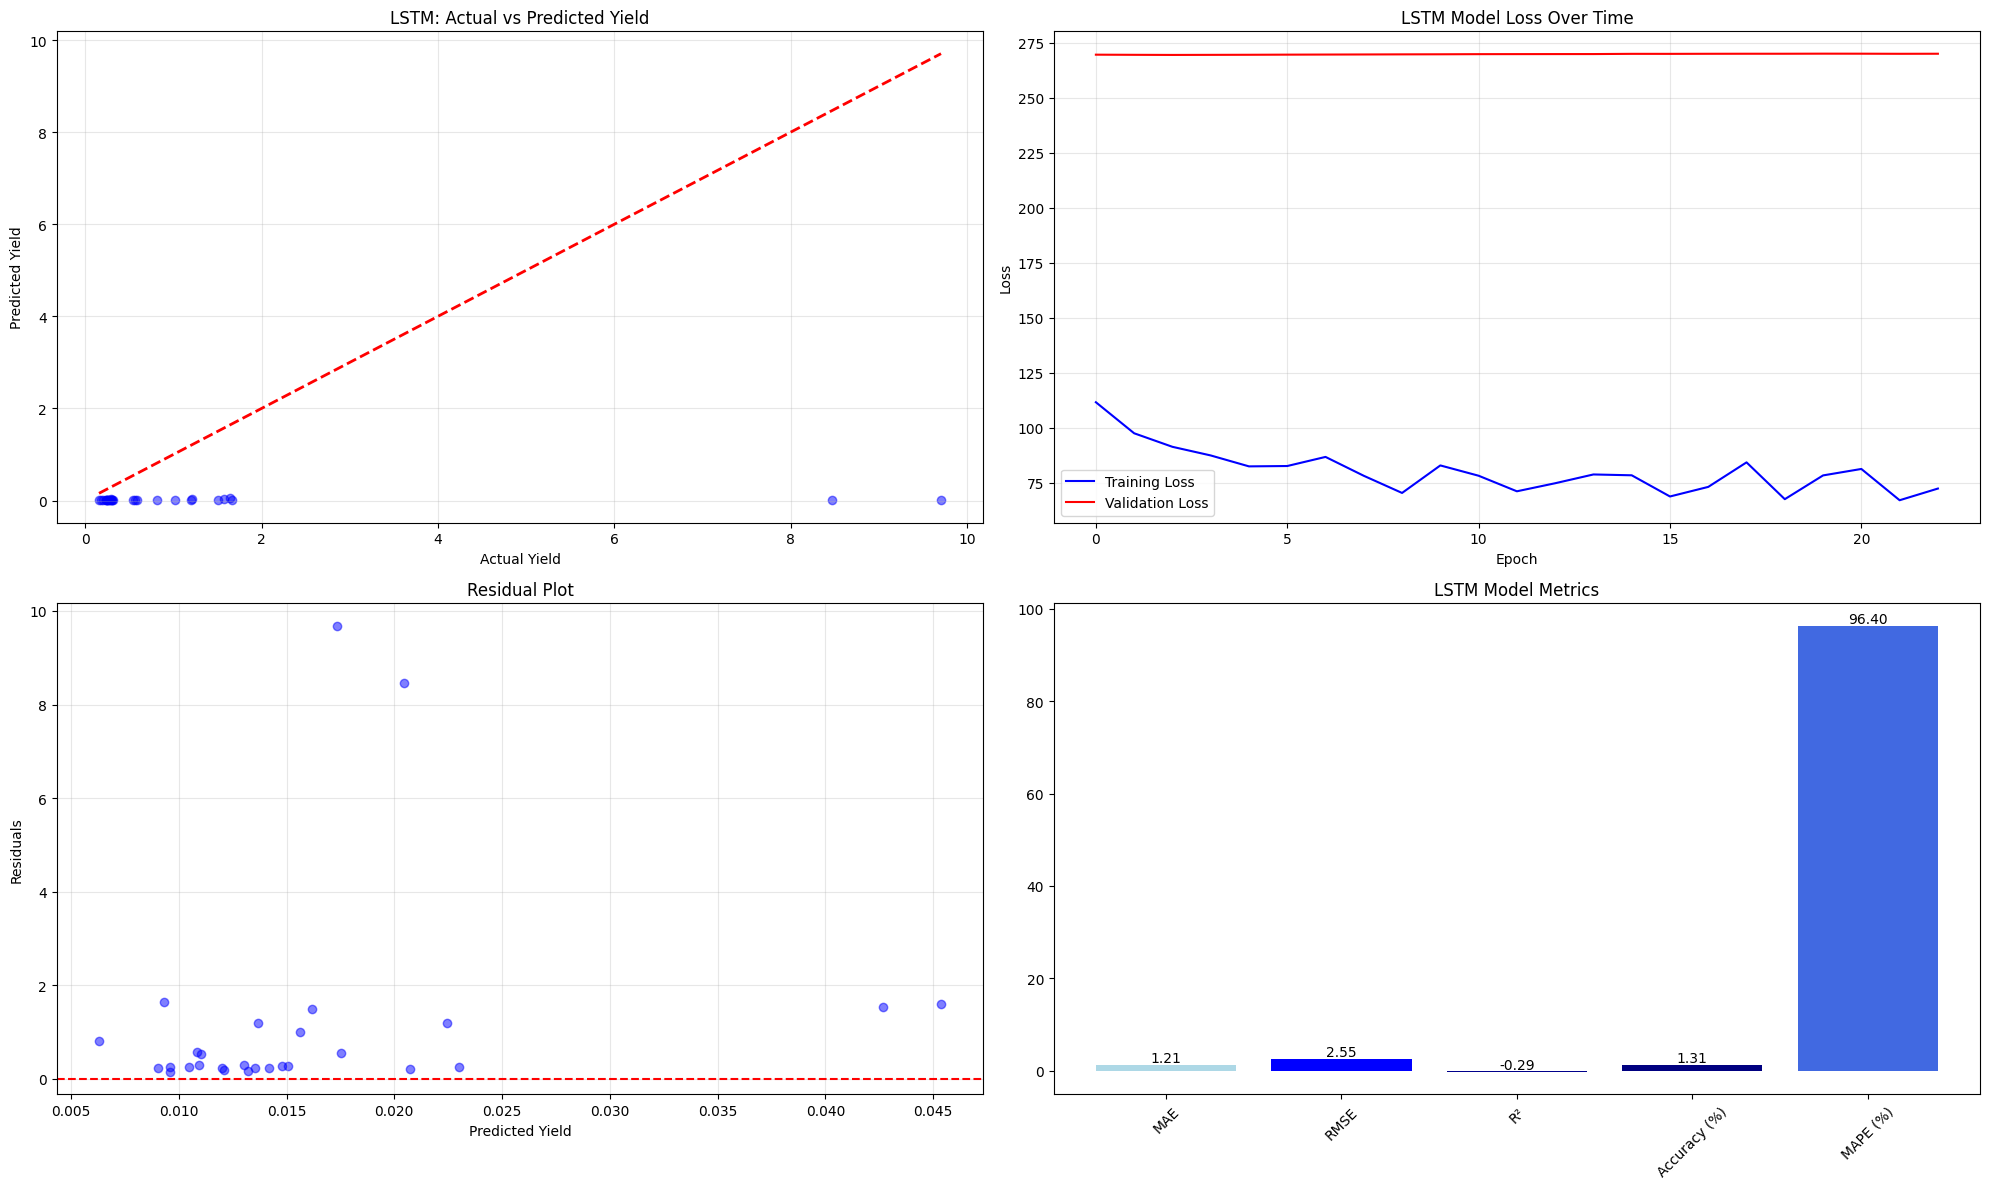

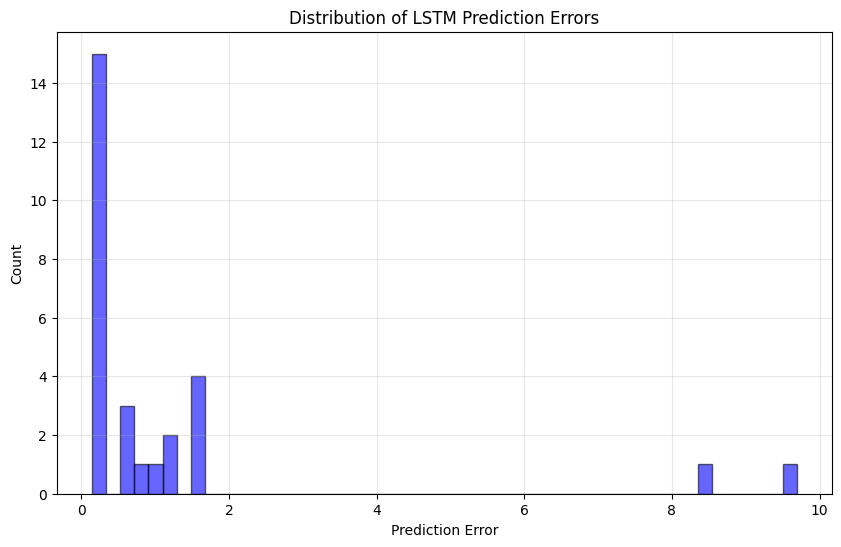

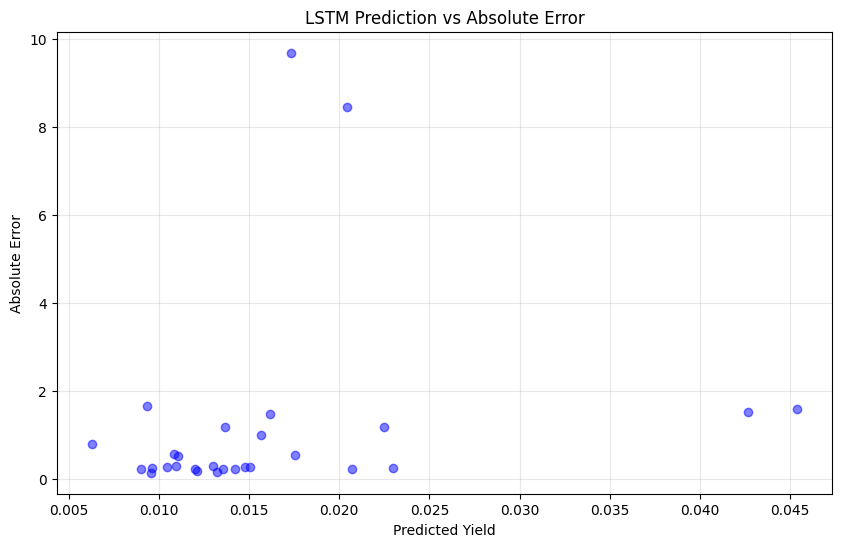

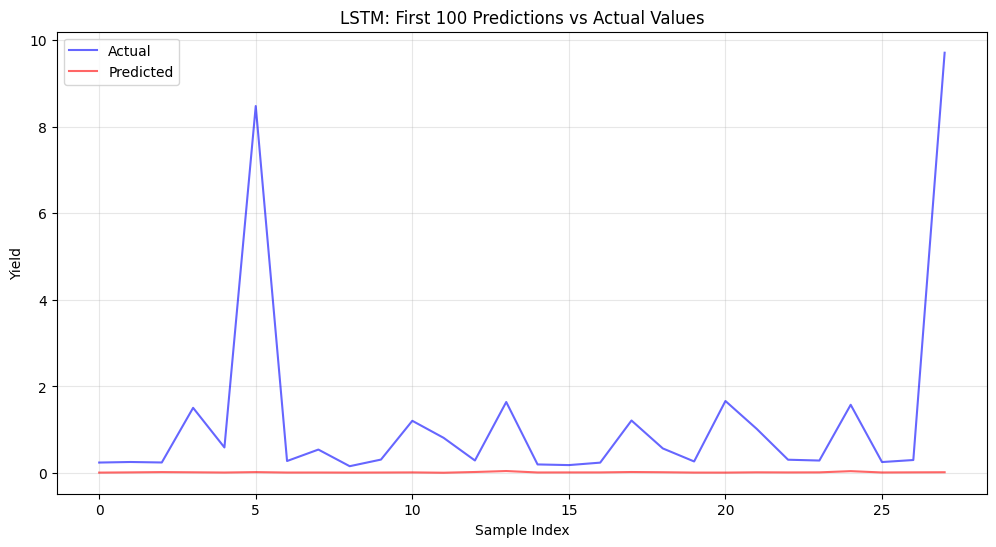


LSTM Model Performance Metrics:
Mean Absolute Error (MAE): 1.2095
Root Mean Square Error (RMSE): 2.5462
R² Score: -0.2894
Model Accuracy: 1.31%
Mean Absolute Percentage Error (MAPE): 96.40%


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def visualize_lstm_results(Y_test, lstm_predictions, history=None):
    lstm_mae            = mean_absolute_error(Y_test, lstm_predictions)
    lstm_rmse           = np.sqrt(mean_squared_error(Y_test, lstm_predictions))
    lstm_r2             = r2_score(Y_test, lstm_predictions)
    lstm_accuracy_percent = (1 - (lstm_mae / Y_test.mean())) * 100
    lstm_mape           = np.mean(np.abs((Y_test.values.flatten() - lstm_predictions.flatten()) / Y_test.values.flatten())) * 100
    residuals           = Y_test - lstm_predictions.flatten()

    fig = plt.figure(figsize=(20, 12))

    ax1 = plt.subplot(2, 2, 1)
    plt.scatter(Y_test, lstm_predictions, alpha=0.5, color='blue')
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Yield')
    plt.ylabel('Predicted Yield')
    plt.title('LSTM: Actual vs Predicted Yield')
    plt.grid(True, alpha=0.3)

    ax2 = plt.subplot(2, 2, 2)
    if history is not None:
        plt.plot(history.history['loss'],     label='Training Loss',   color='blue')
        plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
        plt.title('LSTM Model Loss Over Time')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

    ax3 = plt.subplot(2, 2, 3)
    plt.scatter(lstm_predictions, residuals, alpha=0.5, color='blue')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Yield')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.grid(True, alpha=0.3)

    ax4 = plt.subplot(2, 2, 4)
    metrics = ['MAE', 'RMSE', 'R²', 'Accuracy (%)', 'MAPE (%)']
    values  = [lstm_mae, lstm_rmse, lstm_r2, lstm_accuracy_percent, lstm_mape]
    colors  = ['lightblue', 'blue', 'darkblue', 'navy', 'royalblue']
    bars = plt.bar(metrics, values, color=colors)
    plt.xticks(rotation=45)
    plt.title('LSTM Model Metrics')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=50, color='blue', alpha=0.6, edgecolor='black')
    plt.title('Distribution of LSTM Prediction Errors')
    plt.xlabel('Prediction Error')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(lstm_predictions, np.abs(residuals), alpha=0.5, color='blue')
    plt.title('LSTM Prediction vs Absolute Error')
    plt.xlabel('Predicted Yield')
    plt.ylabel('Absolute Error')
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(Y_test.values[:100],       label='Actual',    color='blue', alpha=0.6)
    plt.plot(lstm_predictions[:100],    label='Predicted', color='red',  alpha=0.6)
    plt.title('LSTM: First 100 Predictions vs Actual Values')
    plt.xlabel('Sample Index')
    plt.ylabel('Yield')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nLSTM Model Performance Metrics:")
    print(f"Mean Absolute Error (MAE): {lstm_mae:.4f}")
    print(f"Root Mean Square Error (RMSE): {lstm_rmse:.4f}")
    print(f"R² Score: {lstm_r2:.4f}")
    print(f"Model Accuracy: {lstm_accuracy_percent:.2f}%")
    print(f"Mean Absolute Percentage Error (MAPE): {lstm_mape:.2f}%")

visualize_lstm_results(Y_test, lstm_predictions, history=history)

## Comparative Visualization

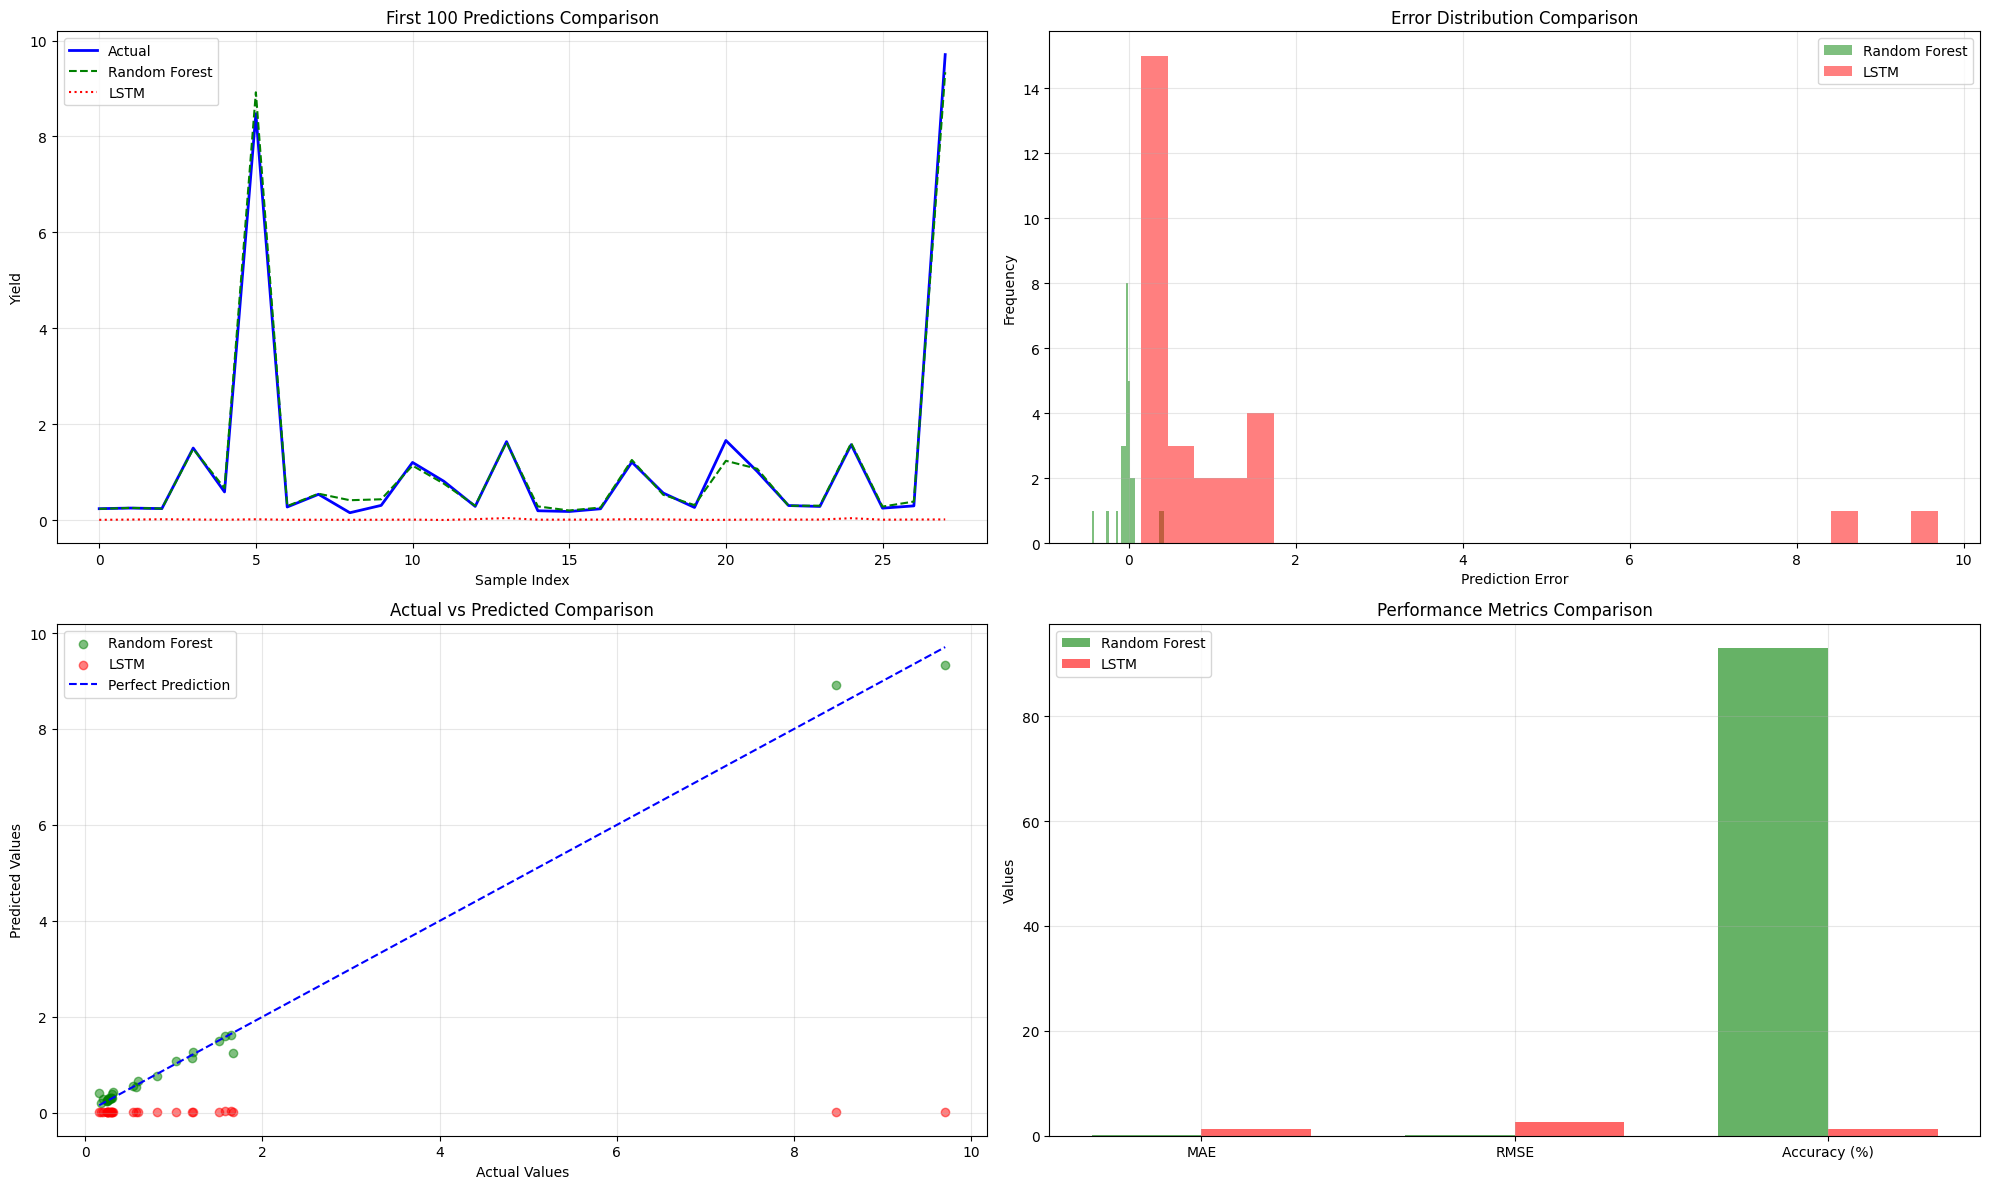


Model Comparison Statistics:
Generated on: 2026-05-19 18:35:56
User: desktop_user

Random Forest Metrics:
  MAE:      0.0860
  RMSE:     0.1512
  Accuracy: 92.98%

LSTM Metrics:
  MAE:      1.2095
  RMSE:     2.5462
  Accuracy: 1.31%

Performance Comparison:
  MAE Difference (RF - LSTM):      -1.1234
  RMSE Difference (RF - LSTM):     -2.3950
  Accuracy Difference (RF - LSTM): 91.67%


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

def compare_models(Y_test, rf_predictions, lstm_predictions, user_login="desktop_user", save_path=None):
    Y_test_array    = np.array(Y_test).flatten()[:100]
    rf_pred_array   = np.array(rf_predictions).flatten()[:100]
    lstm_pred_array = np.array(lstm_predictions).flatten()[:100]

    rf_mae      = np.mean(np.abs(Y_test_array - rf_pred_array))
    rf_rmse     = np.sqrt(np.mean((Y_test_array - rf_pred_array)**2))
    rf_accuracy = (1 - (rf_mae / np.mean(Y_test_array))) * 100

    lstm_mae      = np.mean(np.abs(Y_test_array - lstm_pred_array))
    lstm_rmse     = np.sqrt(np.mean((Y_test_array - lstm_pred_array)**2))
    lstm_accuracy = (1 - (lstm_mae / np.mean(Y_test_array))) * 100

    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    fig = plt.figure(figsize=(20, 12))

    ax1 = plt.subplot(2, 2, 1)
    plt.plot(Y_test_array,    label='Actual',       color='blue',  linewidth=2)
    plt.plot(rf_pred_array,   label='Random Forest', color='green', linestyle='--')
    plt.plot(lstm_pred_array, label='LSTM',          color='red',   linestyle=':')
    plt.title('First 100 Predictions Comparison', fontsize=12)
    plt.xlabel('Sample Index')
    plt.ylabel('Yield')
    plt.grid(True, alpha=0.3)
    plt.legend()

    ax2 = plt.subplot(2, 2, 2)
    rf_errors   = Y_test_array - rf_pred_array
    lstm_errors = Y_test_array - lstm_pred_array
    plt.hist(rf_errors,   bins=30, alpha=0.5, color='green', label='Random Forest')
    plt.hist(lstm_errors, bins=30, alpha=0.5, color='red',   label='LSTM')
    plt.title('Error Distribution Comparison', fontsize=12)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.legend()

    ax3 = plt.subplot(2, 2, 3)
    plt.scatter(Y_test_array, rf_pred_array,   alpha=0.5, color='green', label='Random Forest')
    plt.scatter(Y_test_array, lstm_pred_array, alpha=0.5, color='red',   label='LSTM')
    plt.plot([Y_test_array.min(), Y_test_array.max()],
             [Y_test_array.min(), Y_test_array.max()], 'b--', label='Perfect Prediction')
    plt.title('Actual vs Predicted Comparison', fontsize=12)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True, alpha=0.3)
    plt.legend()

    ax4 = plt.subplot(2, 2, 4)
    metrics    = ['MAE', 'RMSE', 'Accuracy (%)']
    rf_vals    = [rf_mae, rf_rmse, rf_accuracy]
    lstm_vals  = [lstm_mae, lstm_rmse, lstm_accuracy]
    x = np.arange(len(metrics))
    w = 0.35
    ax4.bar(x - w/2, rf_vals,   w, label='Random Forest', color='green', alpha=0.6)
    ax4.bar(x + w/2, lstm_vals, w, label='LSTM',          color='red',   alpha=0.6)
    ax4.set_ylabel('Values')
    ax4.set_title('Performance Metrics Comparison', fontsize=12)
    ax4.set_xticks(x)
    ax4.set_xticklabels(metrics)
    ax4.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print("\nModel Comparison Statistics:")
    print(f"Generated on: {current_time}")
    print(f"User: {user_login}")
    print("\nRandom Forest Metrics:")
    print(f"  MAE:      {rf_mae:.4f}")
    print(f"  RMSE:     {rf_rmse:.4f}")
    print(f"  Accuracy: {rf_accuracy:.2f}%")
    print("\nLSTM Metrics:")
    print(f"  MAE:      {lstm_mae:.4f}")
    print(f"  RMSE:     {lstm_rmse:.4f}")
    print(f"  Accuracy: {lstm_accuracy:.2f}%")
    print("\nPerformance Comparison:")
    print(f"  MAE Difference (RF - LSTM):      {rf_mae - lstm_mae:.4f}")
    print(f"  RMSE Difference (RF - LSTM):     {rf_rmse - lstm_rmse:.4f}")
    print(f"  Accuracy Difference (RF - LSTM): {rf_accuracy - lstm_accuracy:.2f}%")

compare_models(Y_test, rf_predictions, lstm_predictions)

## Sample Output

In [18]:
import pandas as pd

results_df = pd.DataFrame({
    'True Values':               Y_test.values.flatten(),
    'Random Forest Predictions': rf_predictions.flatten(),
    'LSTM Predictions':          lstm_predictions.flatten()
})

print("Sample Predictions:")
print(results_df.head(10))

Sample Predictions:
   True Values  Random Forest Predictions  LSTM Predictions
0     0.241250                   0.237659          0.009020
1     0.254074                   0.257915          0.014198
2     0.242857                   0.244027          0.020726
3     1.505217                   1.486980          0.016160
4     0.590000                   0.669267          0.010841
5     8.475517                   8.921057          0.020435
6     0.276522                   0.296236          0.010476
7     0.541000                   0.553542          0.011042
8     0.156875                   0.417722          0.009578
9     0.310000                   0.437139          0.010938


## Deployment — Save Models Locally

In [19]:
import joblib
import os
from datetime import datetime

def save_trained_models(rf_model, lstm_model, scaler, base_path="."):
    model_dir = os.path.join(base_path, 'models')
    os.makedirs(model_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    try:
        rf_path     = os.path.join(model_dir, 'random_forest_model.joblib')
        lstm_path   = os.path.join(model_dir, 'lstm_model.h5')
        scaler_path = os.path.join(model_dir, 'scaler.joblib')

        joblib.dump(rf_model, rf_path)
        lstm_model.save(lstm_path)
        joblib.dump(scaler, scaler_path)

        metadata = {'timestamp': timestamp, 'rf_model_path': rf_path,
                    'lstm_model_path': lstm_path, 'scaler_path': scaler_path}
        joblib.dump(metadata, os.path.join(model_dir, 'model_metadata.joblib'))

        print(f"\nModels saved successfully at {timestamp}")
        print(f"Models directory: {os.path.abspath(model_dir)}")
        print(f"- Random Forest: {rf_path}")
        print(f"- LSTM:          {lstm_path}")
        print(f"- Scaler:        {scaler_path}")

    except Exception as e:
        print(f"Error saving models: {str(e)}")
        raise

save_trained_models(rf_model, lstm_model, scaler, base_path=DATA_FOLDER)


Models saved successfully at 2026-05-19 18:35:58
Models directory: C:\Users\KIIT\OneDrive\Desktop\AGRICULTURE\models
- Random Forest: C:\Users\KIIT\OneDrive\Desktop\AGRICULTURE\models\random_forest_model.joblib
- LSTM:          C:\Users\KIIT\OneDrive\Desktop\AGRICULTURE\models\lstm_model.h5
- Scaler:        C:\Users\KIIT\OneDrive\Desktop\AGRICULTURE\models\scaler.joblib


## Predict New Input

In [20]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import os

def prepare_input_data(crop_year, area, production, annual_rainfall, fertilizer,
                       pesticide, average_mean, crop_name, season_name):
    # Crops and seasons matching the training data
    crops = sorted(['Groundnut', 'Horse-gram', 'Jute', 'Maize', 'Moong(Green Gram)',
                    'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Sesamum',
                    'Sugarcane', 'Urad', 'Wheat'])
    seasons = sorted(df_processed['Season'].unique().tolist())

    data = {
        'Crop_Year':       crop_year,
        'Area':            area,
        'Production':      production,
        'Annual_Rainfall': annual_rainfall,
        'Fertilizer':      fertilizer,
        'Pesticide':       pesticide,
        'AVERAGE MEAN':    average_mean
    }
    for crop in crops[1:]:   # drop='first' removes first crop
        data[f'Crop_{crop}'] = 1 if crop == crop_name else 0
    for season in seasons[1:]:  # drop='first' removes first season
        data[f'Season_{season}'] = 1 if season == season_name else 0

    return pd.DataFrame([data])

def predict_yield(crop_year, area, annual_rainfall, fertilizer, pesticide,
                  average_mean, crop_name, season_name, base_path="."):
    try:
        input_data = prepare_input_data(
            crop_year=crop_year, area=area, production=0,
            annual_rainfall=annual_rainfall, fertilizer=fertilizer,
            pesticide=pesticide, average_mean=average_mean,
            crop_name=crop_name, season_name=season_name
        )

        model_dir   = os.path.join(base_path, 'models')
        rf_m        = joblib.load(os.path.join(model_dir, 'random_forest_model.joblib'))
        lstm_m      = tf.keras.models.load_model(os.path.join(model_dir, 'lstm_model.h5'), compile=False)
        scaler_m    = joblib.load(os.path.join(model_dir, 'scaler.joblib'))

        scaled_data = scaler_m.transform(input_data)
        rf_pred     = rf_m.predict(scaled_data)
        lstm_pred   = lstm_m.predict(scaled_data.reshape(-1, 1, scaled_data.shape[1]), verbose=0).flatten()

        return {'random_forest': rf_pred[0], 'lstm': lstm_pred[0]}

    except Exception as e:
        print(f"Prediction Error: {str(e)}")
        return None

# ─────────────────────────────────────────────────
# Example prediction — edit values as needed
# ─────────────────────────────────────────────────
result = predict_yield(
    crop_year=2009,
    area=100,
    annual_rainfall=1500,
    fertilizer=50000,
    pesticide=100,
    average_mean=27.37,
    crop_name="Rice",
    season_name="Kharif",
    base_path=DATA_FOLDER
)

if result:
    print(f"\nPredicted Yield:")
    print(f"  Random Forest: {result['random_forest']:.4f}")
    print(f"  LSTM:          {result['lstm']:.4f}")


Predicted Yield:
  Random Forest: 0.3800
  LSTM:          0.0163


## Model Information

In [21]:
import joblib
import tensorflow as tf
import os

def get_model_info(base_path="."):
    try:
        model_dir = os.path.join(base_path, 'models')
        rf_m      = joblib.load(os.path.join(model_dir, 'random_forest_model.joblib'))
        lstm_m    = tf.keras.models.load_model(os.path.join(model_dir, 'lstm_model.h5'), compile=False)

        info = {
            'numeric_features': ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall',
                                 'Fertilizer', 'Pesticide', 'AVERAGE MEAN'],
            'available_crops':   sorted(df_processed['Crop'].unique().tolist()),
            'available_seasons': sorted(df_processed['Season'].unique().tolist()),
            'random_forest': {
                'type':         type(rf_m).__name__,
                'n_estimators': rf_m.n_estimators,
                'max_depth':    rf_m.max_depth
            },
            'lstm': {
                'type':         'LSTM',
                'layers':       [layer.name for layer in lstm_m.layers],
                'input_shape':  lstm_m.input_shape,
                'output_shape': lstm_m.output_shape
            }
        }
        return info
    except Exception as e:
        print(f"Error: {str(e)}")
        return None

info = get_model_info(base_path=DATA_FOLDER)
if info:
    print("\nNumeric Features:",    info['numeric_features'])
    print("\nAvailable Crops:",     info['available_crops'])
    print("\nAvailable Seasons:",   info['available_seasons'])
    print("\nRandom Forest:",       info['random_forest'])
    print("\nLSTM layers:",         info['lstm']['layers'])


Numeric Features: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'AVERAGE MEAN']

Available Crops: ['Groundnut', 'Horse-gram', 'Jute', 'Maize', 'Moong(Green Gram)', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Sesamum', 'Sugarcane', 'Urad', 'Wheat']

Available Seasons: ['Autumn     ', 'Summer     ', 'Winter     ']

Random Forest: {'type': 'RandomForestRegressor', 'n_estimators': 100, 'max_depth': None}

LSTM layers: ['lstm', 'batch_normalization', 'dropout', 'lstm_1', 'batch_normalization_1', 'dropout_1', 'dense', 'batch_normalization_2', 'dropout_2', 'dense_1', 'batch_normalization_3', 'dense_2']


## Workflow Diagram

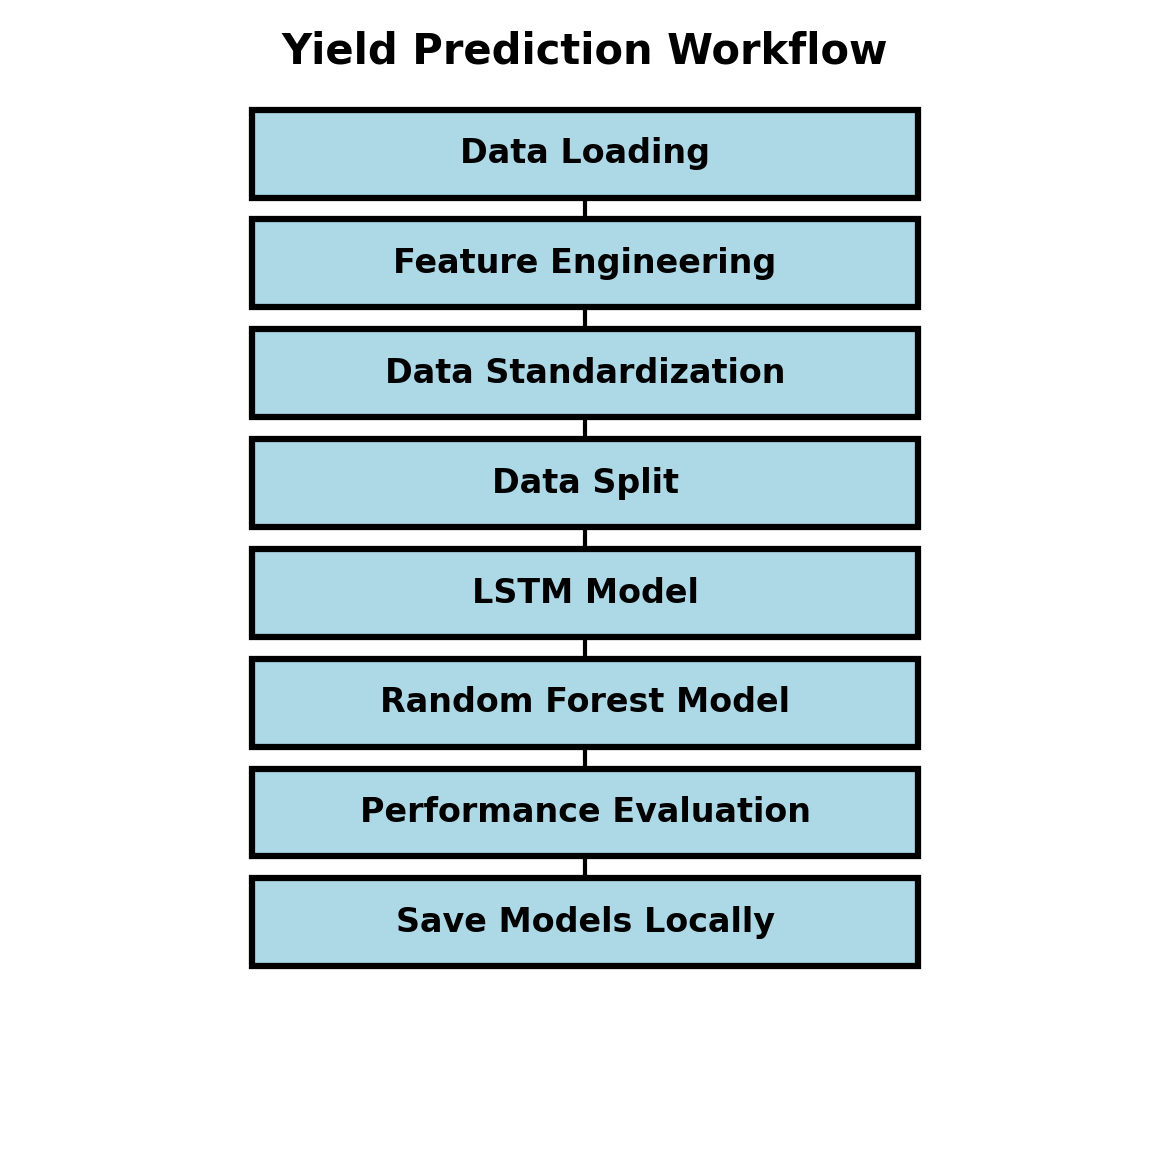

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)

boxes = [
    {"name": "Data Loading",          "xy": (0.2, 0.85), "width": 0.6, "height": 0.08},
    {"name": "Feature Engineering",   "xy": (0.2, 0.75), "width": 0.6, "height": 0.08},
    {"name": "Data Standardization",  "xy": (0.2, 0.65), "width": 0.6, "height": 0.08},
    {"name": "Data Split",            "xy": (0.2, 0.55), "width": 0.6, "height": 0.08},
    {"name": "LSTM Model",            "xy": (0.2, 0.45), "width": 0.6, "height": 0.08},
    {"name": "Random Forest Model",   "xy": (0.2, 0.35), "width": 0.6, "height": 0.08},
    {"name": "Performance Evaluation","xy": (0.2, 0.25), "width": 0.6, "height": 0.08},
    {"name": "Save Models Locally",   "xy": (0.2, 0.15), "width": 0.6, "height": 0.08},
]

for box in boxes:
    ax.add_patch(patches.Rectangle(
        box["xy"], box["width"], box["height"],
        facecolor="lightblue", edgecolor="black", linewidth=1.5, zorder=2))
    ax.text(box["xy"][0] + box["width"]/2, box["xy"][1] + box["height"]/2,
            box["name"], ha="center", va="center", fontsize=8, fontweight='bold', zorder=3)

for i in range(len(boxes) - 1):
    ax.annotate("",
        xy   =(boxes[i+1]["xy"][0] + boxes[i+1]["width"]/2, boxes[i+1]["xy"][1] + 0.01),
        xytext=(boxes[i]["xy"][0]  + boxes[i]["width"]/2,   boxes[i]["xy"][1]   + boxes[i]["height"] - 0.01),
        arrowprops=dict(arrowstyle="-", color="black", shrinkA=0, shrinkB=0), zorder=1)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.title("Yield Prediction Workflow", fontsize=10, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

## Hyperparameter & Results Summary

In [23]:
import pandas as pd

hyperparameter_data = {
    'Model':         ['Random Forest', 'LSTM'],
    'n_estimators':  [100, 'N/A'],
    'random_state':  [42, 'N/A'],
    'learning_rate': ['N/A', 0.001],
    'epochs':        ['N/A', 100],
    'batch_size':    ['N/A', 32],
}
hyperparameter_table = pd.DataFrame(hyperparameter_data)

results_data = {
    'Metric':         ['MAE', 'RMSE', 'R²', 'Accuracy (%)', 'MAPE (%)'],
    'Random Forest':  [rf_mae, rf_rmse, rf_r2, rf_accuracy_percent, rf_mape],
    'LSTM':           [lstm_mae, lstm_rmse, lstm_r2, lstm_accuracy_percent, lstm_mape],
}
results_table = pd.DataFrame(results_data)

print("Hyperparameter Summary:\n", hyperparameter_table)
print("\nModel Results Comparison:\n", results_table)

Hyperparameter Summary:
            Model n_estimators random_state learning_rate epochs batch_size
0  Random Forest          100           42           N/A    N/A        N/A
1           LSTM          N/A          N/A         0.001    100         32

Model Results Comparison:
          Metric  Random Forest       LSTM
0           MAE       0.086047   1.209496
1          RMSE       0.151212   2.546163
2            R²       0.995452  -0.289407
3  Accuracy (%)      92.979018   1.311601
4      MAPE (%)      15.771991  96.398448


In [24]:
import scipy.stats as stats

rf_preds_series   = results_df['Random Forest Predictions']
lstm_preds_series = results_df['LSTM Predictions']

t_statistic, p_value = stats.ttest_rel(rf_preds_series, lstm_preds_series)

print("T-statistic:", t_statistic)
print("P-value:",     p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between Random Forest and LSTM predictions.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between Random Forest and LSTM predictions.")

T-statistic: 2.851949688462976
P-value: 0.008232681751783854
Reject the null hypothesis: There is a significant difference between Random Forest and LSTM predictions.
